In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import lsstypes as types
sys.path.insert(0, '/global/u1/q/qinxunli/dev/desi-clustering')
from clustering_statistics.tools import get_stats_fn
from mpytools import Catalog
from matplotlib import pyplot as plt
import h5py

In [2]:
stats_dir=Path(Path(os.getenv('SCRATCH')) / 'clustering-measurements-checks')
mock_ver='holi-v1-altmtl'
imock=451
weight='default-FKP'
tracer='LRG'
zbins=(0.4,0.6)
region='NGC'

In [3]:
# check the catalog
recon_dat_fn = stats_dir / f'jax_recon_{tracer}_{region}_clustering.dat.h5'
dat = Catalog.read(recon_dat_fn)
recon_ran_fn = stats_dir / f'jax_recon_{tracer}_0_{region}_clustering.ran.h5'
ran = Catalog.read(recon_ran_fn)


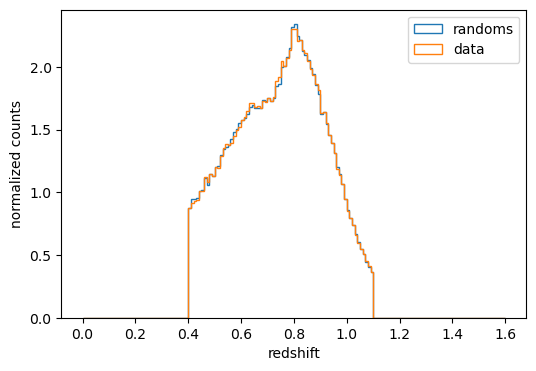

In [4]:
# check the n(z)
fig, ax = plt.subplots(1,1, figsize=(6,4))
nbin = 160
dat_z = dat['Z']
ran_z = ran['Z']
ax.hist(ran_z, bins=nbin, range=(0.0,1.6), histtype='step', label='randoms', density=True)
ax.hist(dat_z, bins=nbin, range=(0.0,1.6), histtype='step', label='data', density=True)
ax.set_xlabel('redshift')
ax.set_ylabel('normalized counts')
ax.legend()

/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_LRG_z0.4-0.6_NGC_weight-default-FKP_nran7_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_LRG_z0.4-0.6_NGC_weight-default-FKP_nran6_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_LRG_z0.4-0.6_NGC_weight-default-FKP_nran5_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_LRG_z0.4-0.6_NGC_weight-default-FKP_nran4_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_LRG_z0.4-0.6_NGC_weight-default-FKP_nran3_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_mesh2_spectrum_LRG_z0.4-0.6_NGC_weight-default-FKP_nran2_451.h5


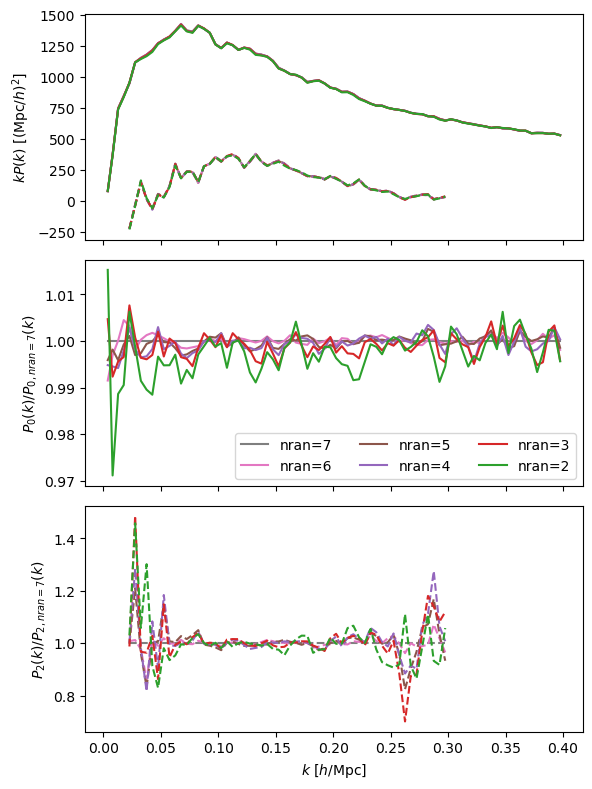

In [5]:
fig, axs = plt.subplots(3,1, figsize=(6,8), sharex=True, height_ratios=[1,1,1])
for nran in range(7,1,-1):
    recon_ps_fn = get_stats_fn(stats_dir=stats_dir, kind='recon_mesh2_spectrum', version=mock_ver, imock=imock, weight=weight, tracer=tracer, zrange=zbins, region=region, extra=f'nran{nran}')
    print(recon_ps_fn)
    spectrum = types.read(recon_ps_fn)
    # print(spectrum, f"with k-average: {spectrum.get(ells=0).coords('k')}")
    spectrum = spectrum.select(k=slice(0, None, 5))  # rebin to dk = 0.005 h/Mpc
    spectrum = spectrum.select(k=(0., 0.4))  # select k-range
    spectrum = spectrum.get(ells=[0, 2])  # monopole and quadrupole
    spectrum = spectrum.at(ells=[2]).select(k=(0.02, 0.3))  # apply stricter k-cut to the quadrupole

    if nran==7:
        poles0 = []
    for i, ell in enumerate(spectrum.ells):
        pole = spectrum.get(ell)
        k=pole.coords('k')
        axs[0].plot(k, k*pole.value(), color=f'C{nran}', linestyle=['-', '--'][i])
        if nran==7:
            poles0.append(pole.value())
        axs[i+1].plot(k, pole.value()/poles0[i], color=f'C{nran}', linestyle=['-', '--'][i], label=f'nran={nran}')

        # pole.coords('k')  # k-modes
        # pole.value()  # value of the power spectrum multipole

            #print(pole.values('shotnoise'))  # shotnoise
    # spectrum.plot(show=True)
axs[0].set_ylabel(r'$k P(k)$ [$(\mathrm{Mpc}/h)^2$]')
axs[1].set_ylabel(r'$P_0(k)/P_{0,nran=7}(k)$')
axs[2].set_ylabel(r'$P_2(k)/P_{2,nran=7}(k)$')
axs[2].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
axs[1].legend(ncol=3)
fig.tight_layout()
# ax=fig.get_axes()[0]
# ax.set_ylim(0,5000)
# fig.show()

/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran7_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran6_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran5_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran4_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran3_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_nran2_451.h5


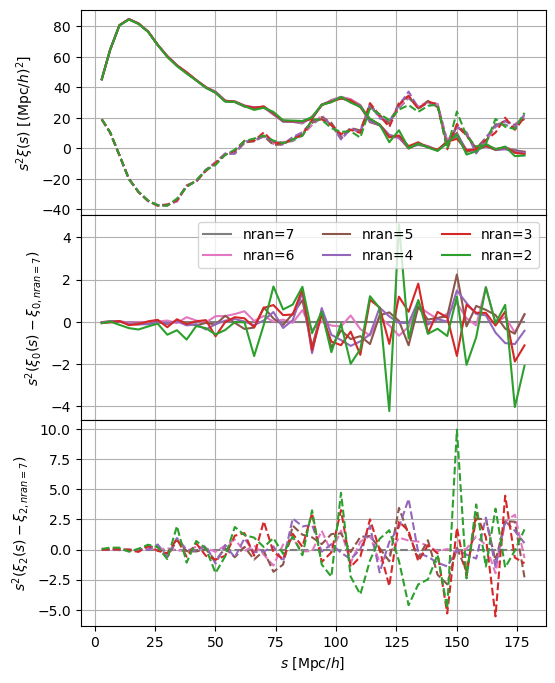

In [26]:
# plot recon correlation function multipoles
fig, axs = plt.subplots(3,1, figsize=(6,8), sharex=True, height_ratios=[1,1,1])
for nran in range(7,1,-1):
    recon_cf_fn = get_stats_fn(stats_dir=stats_dir, kind='recon_particle2_correlation', version=mock_ver, imock=imock, weight=weight, tracer=tracer, zrange=zbins, region=region, extra=f'nran{nran}')
    corr = types.read(recon_cf_fn)
    print(recon_cf_fn)

    # Rebinning
    corr = corr.select(s=slice(0, None, 4))
    # corr = corr.select(s=(60., 150)) 
    
    # To multipoles
    xi = corr.project(ells=[0, 2])
    s = corr.coords('s')

    if nran==7:
        poles0 = []
    for i, ell in enumerate(xi.ells):
        pole = xi.get(ell)
        axs[0].plot(s, s*s*pole.value(), color=f'C{nran}', linestyle=['-', '--'][i])

        if nran==7:
            poles0.append(pole.value())
        axs[i+1].plot(s, s*s*(pole.value()-poles0[i]), color=f'C{nran}', linestyle=['-', '--'][i], label=f'nran={nran}')
axs[0].set_ylabel(r'$s^2 \xi(s)$ [$(\mathrm{Mpc}/h)^2$]')
axs[1].set_ylabel(r'$s^2(\xi_0(s)-\xi_{0,nran=7})$')
axs[2].set_ylabel(r'$s^2(\xi_2(s)-\xi_{2,nran=7})$')
axs[2].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
axs[1].legend(ncol=3)
for ax in axs:
    ax.grid()
plt.subplots_adjust(hspace=0.)
        


/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_cellsize6_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_cellsize7_451.h5
/pscratch/sd/q/qinxunli/clustering-measurements-checks/holi-v1-altmtl/recon_particle2_correlation_LRG_z0.4-0.6_NGC_weight-default-FKP_cellsize8_451.h5


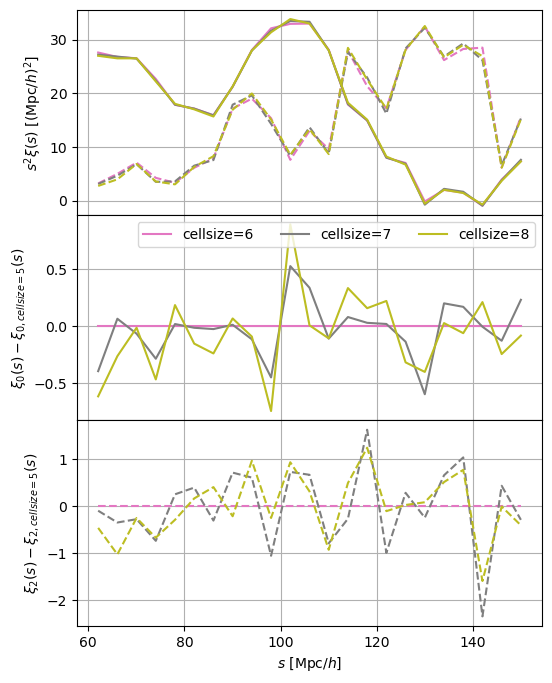

In [25]:
# plot recon correlation function multipoles
fig, axs = plt.subplots(3,1, figsize=(6,8), sharex=True, height_ratios=[1,1,1])
for cellsize in range(6,9):
    recon_cf_fn = get_stats_fn(stats_dir=stats_dir, kind='recon_particle2_correlation', version=mock_ver, imock=imock, weight=weight, tracer=tracer, zrange=zbins, region=region, extra=f'cellsize{cellsize}')
    corr = types.read(recon_cf_fn)
    print(recon_cf_fn)

    # Rebinning
    corr = corr.select(s=slice(0, None, 4))
    corr = corr.select(s=(60., 150)) 
    
    # To multipoles
    xi = corr.project(ells=[0, 2])
    s = corr.coords('s')

    if cellsize==6:
        poles0 = []
    for i, ell in enumerate(xi.ells):
        pole = xi.get(ell)
        axs[0].plot(s, s*s*pole.value(), color=f'C{cellsize}', linestyle=['-', '--'][i])

        if cellsize==6:
            poles0.append(pole.value())
        axs[i+1].plot(s, s*s*(pole.value()-poles0[i]), color=f'C{cellsize}', linestyle=['-', '--'][i], label=f'cellsize={cellsize}')

axs[0].set_ylabel(r'$s^2 \xi(s)$ [$(\mathrm{Mpc}/h)^2$]')
axs[1].set_ylabel(r'$\xi_0(s)-\xi_{0,cellsize=5}(s)$')
axs[2].set_ylabel(r'$\xi_2(s)-\xi_{2,cellsize=5}(s)$')
axs[2].set_xlabel(r'$s$ [$\mathrm{Mpc}/h$]')
axs[1].legend(ncol=3)
for ax in axs:
    ax.grid()   
plt.subplots_adjust(hspace=0.)